In [1]:
!pip install pdfplumber spacy nltk PyMuPDF

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import pdfplumber
import re
import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

In [12]:
import pandas as pd
import numpy as np
import re

In [4]:
from google.colab import files

uploaded = files.upload()

Saving resume_data.csv to resume_data.csv


In [30]:
from google.colab import files

uploaded = files.upload()

Saving DataAnalyst.csv.zip to DataAnalyst.csv.zip


In [33]:
import pandas as pd
job_df = pd.read_csv("DataAnalyst.csv.zip")

In [34]:
resume_df = pd.read_csv("/content/resume_data.csv")
job_df = pd.read_csv("/content/DataAnalyst.csv.zip")

In [46]:
resume_df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [49]:
print(resume_df.columns.tolist())

['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']


In [35]:
job_df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [36]:
print(job_df.columns.tolist())

['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply']


In [38]:
print(job_df["Job Title"].unique())

['Data Analyst, Center on Immigration and Justice (CIJ)'
 'Quality Data Analyst'
 'Senior Data Analyst, Insights & Analytics Team [Customer Operations]'
 ... 'Senior Data Analyst (Corporate Audit)'
 'Technical Business Analyst (SQL, Data analytics, ETL)'
 'Senior Quality Data Analyst']


In [52]:
print(job_df.columns.tolist())

['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply']


In [43]:
selected_job = "Data Analyst"

In [50]:
resume_df.columns = resume_df.columns.str.replace('\ufeff', '', regex=False)

In [53]:
resume_df.columns = resume_df.columns.str.replace('\ufeff', '', regex=False)

job_df.columns = (
    job_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(job_df.columns.tolist())

['unnamed:_0', 'job_title', 'salary_estimate', 'job_description', 'rating', 'company_name', 'location', 'headquarters', 'size', 'founded', 'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors', 'easy_apply']


In [54]:
skills_list = [
    "python", "sql", "excel", "power bi", "tableau", "statistics",
    "machine learning", "deep learning", "pandas", "numpy",
    "scikit-learn", "tensorflow", "pytorch", "aws", "azure",
    "spark", "hadoop", "etl", "data visualization", "git",
    "linux", "sas", "r", "communication"
]

In [55]:
selected_job = job_df.iloc[0]

print(selected_job["job_title"])

Data Analyst, Center on Immigration and Justice (CIJ)


In [39]:

phone = re.findall(r'(\+?\d[\d\s\-]{8,15}\d)', text)

if phone:
    print("Phone:", phone[0])
else:
    print("Phone Not Found")

Phone Not Found


In [40]:
doc = nlp(text)

name = ""

for ent in doc.ents:
    if ent.label_ == "PERSON":
        name = ent.text
        break

print("Name:", name)

Name: 


In [56]:
job_description = str(selected_job["job_description"]).lower()

required_skills = []

for skill in skills_list:
    if skill in job_description:
        required_skills.append(skill)

print("Required Skills:")
print(required_skills)

Required Skills:
['python', 'sql', 'statistics', 'aws', 'git', 'r']


In [57]:
candidate_skills = str(resume_df.iloc[0]["skills"]).lower()

candidate_skills = [
    skill.strip()
    for skill in candidate_skills.split(",")
]

print(candidate_skills)

["['big data'", "'hadoop'", "'hive'", "'python'", "'mapreduce'", "'spark'", "'java'", "'machine learning'", "'cloud'", "'hdfs'", "'yarn'", "'core java'", "'data science'", "'c++'", "'data structures'", "'dbms'", "'rdbms'", "'informatica'", "'talend'", "'amazon redshift'", "'microsoft azure']"]


In [58]:
matched_skills = list(set(candidate_skills) & set(required_skills))

missing_skills = list(set(required_skills) - set(candidate_skills))

print("Matched Skills:", matched_skills)
print("Missing Skills:", missing_skills)

Matched Skills: []
Missing Skills: ['sql', 'r', 'python', 'git', 'aws', 'statistics']


In [59]:
if len(required_skills) > 0:
    match_percentage = (len(matched_skills) / len(required_skills)) * 100
else:
    match_percentage = 0

print(f"Skill Match: {match_percentage:.2f}%")

Skill Match: 0.00%


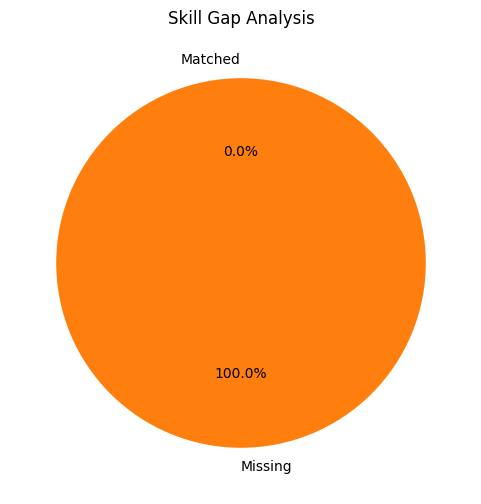

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    [len(matched_skills), len(missing_skills)],
    labels=["Matched", "Missing"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Skill Gap Analysis")
plt.show()

In [61]:
##05_ATS_Score_Calculator.ipynb

In [62]:
import pandas as pd
import re

In [63]:
resume_df.columns = resume_df.columns.str.replace('\ufeff', '', regex=False)

job_df.columns = (
    job_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [64]:
resume = resume_df.iloc[0]
job = job_df.iloc[0]

In [65]:
skills_list = [
    "python","sql","excel","power bi","tableau","statistics",
    "machine learning","deep learning","pandas","numpy",
    "scikit-learn","tensorflow","aws","azure","spark",
    "hadoop","etl","git","linux","communication"
]

job_description = str(job["job_description"]).lower()

required_skills = [
    skill for skill in skills_list
    if skill in job_description
]

In [66]:
candidate_text = str(resume["skills"]).lower()

candidate_skills = [
    skill.strip()
    for skill in candidate_text.split(",")
]

In [68]:
print(required_skills)
print("Number of required skills:", len(required_skills))

['python', 'sql', 'statistics', 'aws', 'git']
Number of required skills: 5


In [69]:
print(candidate_skills)
print("Number of candidate skills:", len(candidate_skills))

["['big data'", "'hadoop'", "'hive'", "'python'", "'mapreduce'", "'spark'", "'java'", "'machine learning'", "'cloud'", "'hdfs'", "'yarn'", "'core java'", "'data science'", "'c++'", "'data structures'", "'dbms'", "'rdbms'", "'informatica'", "'talend'", "'amazon redshift'", "'microsoft azure']"]
Number of candidate skills: 21


In [71]:
print(resume["skills"])

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']


In [72]:
candidate_skills = [skill.strip() for skill in candidate_text.split(",")]

In [73]:
print(job["job_description"][:1000])

Are you eager to roll up your sleeves and harness data to drive policy change? Do you enjoy sifting through complex datasets to illuminate trends and insights? Do you see yourself working for a values-driven organization with a vision to tackle the most pressing injustices of our day?

We are looking to hire a bright, hard-working, and creative individual with strong data management skills and a demonstrated commitment to immigrant's rights. The Data Analyst will assist with analysis and reporting needs for Veras Center on Immigration and Justice (CIJ), working across its current projects and future Vera initiatives.

Who we are:

Founded in 1961, The Vera Institute is an independent, non-partisan, nonprofit organization that combines expertise in research, technical assistance, and demonstration projects to assist leaders in government and civil society examine justice policy and practice, and improve the systems people rely on for justice and safety.
We study problems that impede hum

In [74]:
print(resume["skills"])

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']


In [75]:
print(required_skills)

['python', 'sql', 'statistics', 'aws', 'git']


In [78]:
import ast

candidate_skills = ast.literal_eval(resume["skills"])

candidate_skills = [skill.lower().strip() for skill in candidate_skills]

print(candidate_skills)

['big data', 'hadoop', 'hive', 'python', 'mapreduce', 'spark', 'java', 'machine learning', 'cloud', 'hdfs', 'yarn', 'core java', 'data science', 'c++', 'data structures', 'dbms', 'rdbms', 'informatica', 'talend', 'amazon redshift', 'microsoft azure']


In [79]:
print(candidate_skills)

['big data', 'hadoop', 'hive', 'python', 'mapreduce', 'spark', 'java', 'machine learning', 'cloud', 'hdfs', 'yarn', 'core java', 'data science', 'c++', 'data structures', 'dbms', 'rdbms', 'informatica', 'talend', 'amazon redshift', 'microsoft azure']


In [80]:
matched = list(set(candidate_skills) & set(required_skills))
print(matched)

['python']


In [81]:
matched = list(set(candidate_skills) & set(required_skills))

missing = list(set(required_skills) - set(candidate_skills))

print("Matched:", matched)
print("Missing:", missing)

Matched: ['python']
Missing: ['git', 'aws', 'sql', 'statistics']


In [82]:
skill_score = (len(matched) / len(required_skills)) * 50

print("Skill Score:", skill_score)

Skill Score: 10.0


In [77]:
print(job["job_description"][:500])

Are you eager to roll up your sleeves and harness data to drive policy change? Do you enjoy sifting through complex datasets to illuminate trends and insights? Do you see yourself working for a values-driven organization with a vision to tackle the most pressing injustices of our day?

We are looking to hire a bright, hard-working, and creative individual with strong data management skills and a demonstrated commitment to immigrant's rights. The Data Analyst will assist with analysis and reporti


In [83]:
matched = list(set(candidate_skills) & set(required_skills))

if len(required_skills) > 0:
    skill_score = (len(matched) / len(required_skills)) * 50
else:
    skill_score = 0

print("Skill Score:", round(skill_score,2))

Skill Score: 10.0


In [84]:
matched = list(set(candidate_skills) & set(required_skills))

if len(required_skills) > 0:
    skill_score = (len(matched) / len(required_skills)) * 50
else:
    skill_score = 0

print("Skill Score:", round(skill_score,2))

Skill Score: 10.0


In [89]:
education = str(resume["degree_names"]).lower()

education_score = 0

if "b.tech" in education or "bachelor" in education:
    education_score = 10

if "m.tech" in education or "master" in education:
    education_score = 15

print("Education Score:", education_score)

Education Score: 10


In [85]:
experience = str(resume["experiencere_requirement"]).lower()

numbers = re.findall(r"\d+", experience)

if numbers:
    years = int(numbers[0])
else:
    years = 0

experience_score = min(years * 5, 20)

print("Experience Score:", experience_score)

Experience Score: 5


In [86]:
contact_score = 0

if resume["online_links"] != "Not Available":
    contact_score += 5

if resume["address"] != "Not Available":
    contact_score += 5

print("Contact Score:", contact_score)

Contact Score: 10


In [87]:
important_columns = [
    "skills",
    "degree_names",
    "responsibilities",
    "positions",
    "educational_institution_name"
]

filled = 0

for col in important_columns:
    if str(resume[col]) != "Not Available":
        filled += 1

completeness_score = (filled / len(important_columns)) * 5

print("Completeness Score:", round(completeness_score,2))

Completeness Score: 5.0


In [90]:
ats_score = (
    skill_score +
    education_score +
    experience_score +
    contact_score +
    completeness_score
)

print("="*40)
print(f"Final ATS Score : {ats_score:.2f}/100")
print("="*40)

Final ATS Score : 40.00/100


In [91]:
if ats_score >= 85:
    result = "Excellent Match"

elif ats_score >= 70:
    result = "Good Match"

elif ats_score >= 50:
    result = "Average Match"

else:
    result = "Needs Improvement"

print(result)

Needs Improvement


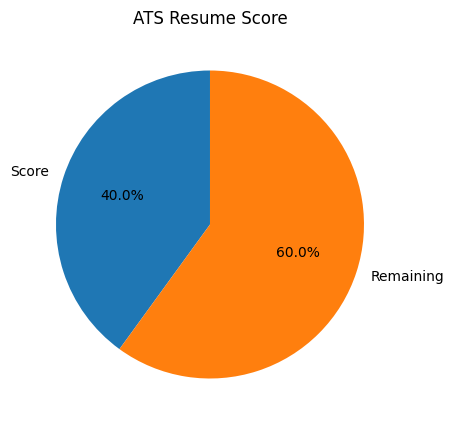

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.pie(
    [ats_score, 100-ats_score],
    labels=["Score", "Remaining"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("ATS Resume Score")
plt.show()

In [93]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.5 MB/s eta 0:00:00


In [94]:
from rapidfuzz import fuzz

matched = []

for req in required_skills:
    for cand in candidate_skills:
        if fuzz.ratio(req, cand) >= 80:
            matched.append(req)
            break

matched = list(set(matched))

print("Matched Skills:", matched)

Matched Skills: ['python']


In [95]:
import plotly.graph_objects as go

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=ats_score,
    title={"text": "ATS Resume Score"},
    gauge={
        "axis": {"range": [0, 100]},
        "bar": {"color": "darkblue"},
        "steps": [
            {"range": [0, 50], "color": "#ff4d4d"},
            {"range": [50, 75], "color": "#ffd633"},
            {"range": [75, 100], "color": "#66cc66"}
        ]
    }
))

fig.show()

In [96]:
#06_AI_Job_Recommendation.ipynb

In [97]:
!pip install scikit-learn

In [98]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [99]:
resume_df.columns = resume_df.columns.str.replace('\ufeff', '', regex=False)

job_df.columns = (
    job_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [100]:
resume_text = str(resume_df.iloc[0]["skills"])

In [101]:
job_descriptions = job_df["job_description"].fillna("")

In [102]:
all_text = [resume_text] + job_descriptions.tolist()

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(all_text)

In [103]:
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
).flatten()

In [104]:
job_df["match_score"] = similarity_scores * 100

In [105]:
top_jobs = job_df.sort_values(
    by="match_score",
    ascending=False
).head(5)

In [106]:
top_jobs[
    [
        "job_title",
        "company_name",
        "location",
        "salary_estimate",
        "match_score"
    ]
]

,job_title,company_name,location,salary_estimate,match_score
1464,Digital S/W Eng Lead Analyst (Big data with SA...,Frontend Arts\n4.5,"Irving, TX",$44K-$78K (Glassdoor est.),22.404471
768,Data Analyst,Diverse Lynx\n3.9,"Chicago, IL",$73K-$82K (Glassdoor est.),21.361431
221,Big Data Programmer Analyst,"TSR, Inc.\n3.6","Jersey City, NJ",$41K-$78K (Glassdoor est.),19.623718
272,Big Data Programmer Analyst,"TSR Consulting Services, Inc.","Jersey City, NJ",$84K-$90K (Glassdoor est.),19.542371
1874,Big data analyst,Data Bridge Consultants,"Charlotte, NC",$53K-$99K (Glassdoor est.),19.027170


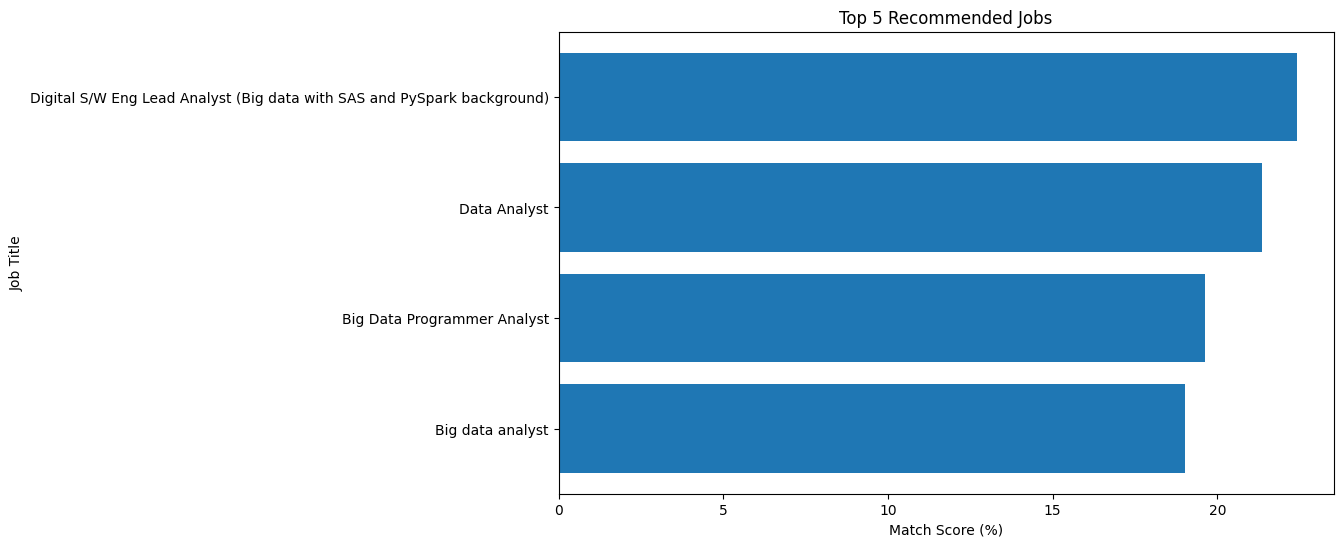

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_jobs["job_title"],
    top_jobs["match_score"]
)

plt.xlabel("Match Score (%)")
plt.ylabel("Job Title")
plt.title("Top 5 Recommended Jobs")

plt.gca().invert_yaxis()

plt.show()

In [108]:
#07_Salary_Insights.ipynb

In [109]:
salary_df = pd.read_csv("/content/ds_salaries.csv")

In [110]:
salary_df.columns = (
    salary_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

salary_df.head()

,unnamed:_0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [111]:
salary_df.info()

salary_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   unnamed:_0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


,unnamed:_0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [112]:
salary_df.info()

salary_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   unnamed:_0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


,unnamed:_0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


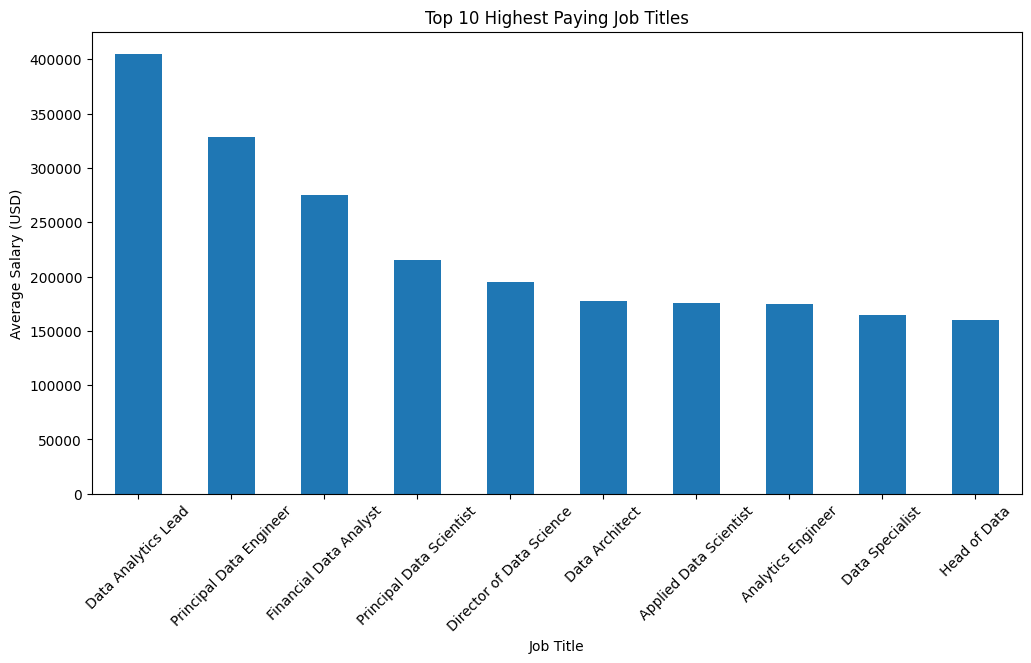

In [113]:
top_jobs = (
    salary_df
    .groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_jobs.plot(kind="bar")

plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=45)

plt.show()

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

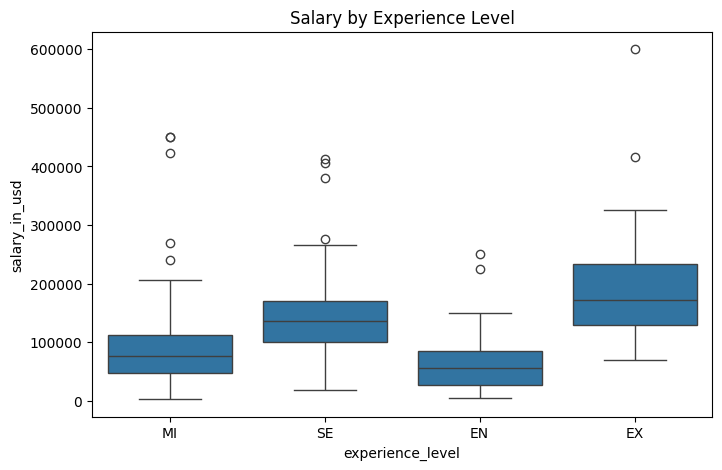

In [116]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=salary_df,
    x="experience_level",
    y="salary_in_usd"
)

plt.title("Salary by Experience Level")

plt.show()

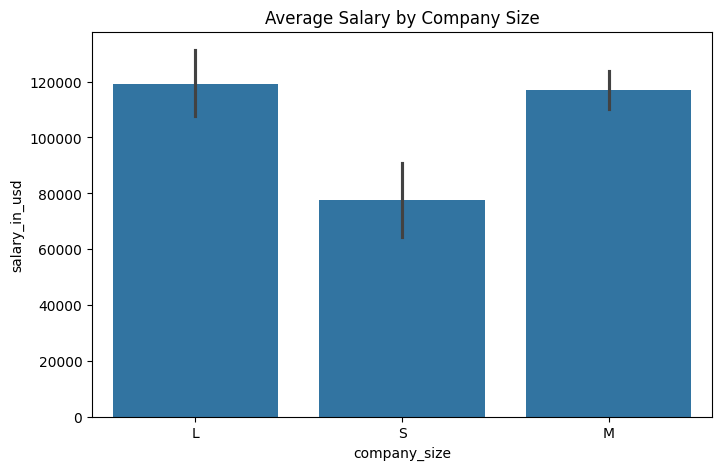

In [118]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=salary_df,
    x="company_size",
    y="salary_in_usd"
)

plt.title("Average Salary by Company Size")

plt.show()

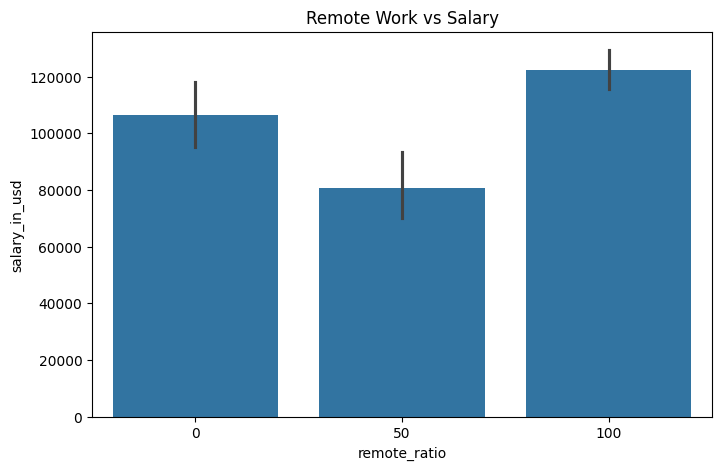

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=salary_df,
    x="remote_ratio",
    y="salary_in_usd"
)

plt.title("Remote Work vs Salary")

plt.show()

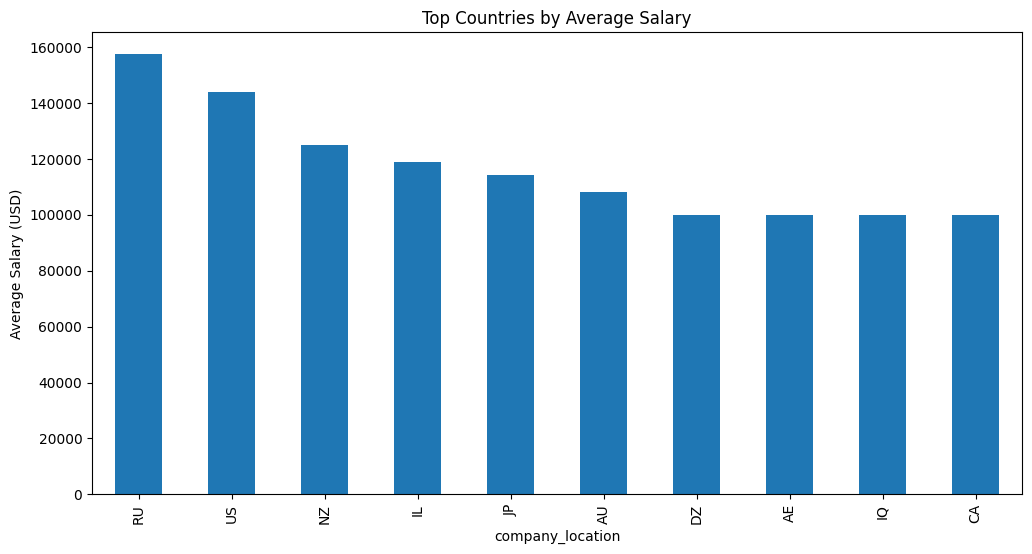

In [120]:
top_country = (
    salary_df
    .groupby("company_location")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_country.plot(kind="bar")

plt.title("Top Countries by Average Salary")

plt.ylabel("Average Salary (USD)")

plt.show()

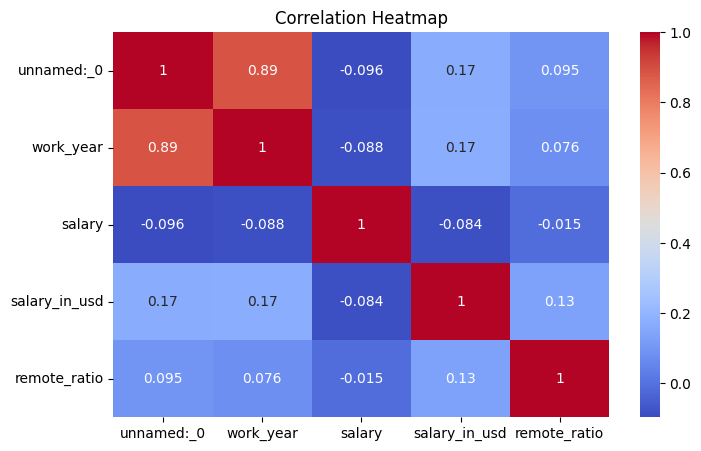

In [121]:
numeric = salary_df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [122]:
print("Highest Paying Job:", top_jobs.index[0])

print("Highest Average Salary:", round(top_jobs.iloc[0],2))

print("Best Paying Country:", top_country.index[0])

print("Highest Country Salary:", round(top_country.iloc[0],2))

Highest Paying Job: Data Analytics Lead
Highest Average Salary: 405000.0
Best Paying Country: RU
Highest Country Salary: 157500.0


In [123]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.8 MB/s eta 0:00:00


In [124]:
import streamlit as st

st.set_page_config(
    page_title="AI Resume & Job Market Analytics",
    layout="wide"
)

st.title("🤖 AI Resume & Job Market Analytics")

st.write("""
Welcome to the AI Resume & Job Market Analytics Dashboard.

### Features:
- 📊 Resume Analytics
- 🎯 ATS Resume Score
- 💼 AI Job Recommendation
- 📈 Salary Insights
- 🧠 Skill Gap Analysis
""")

2026-07-24 13:48:11.206 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.209 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.490 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-24 13:48:11.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [125]:
st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Go to",
    [
        "Home",
        "EDA",
        "Skill Gap",
        "ATS Score",
        "Job Recommendation",
        "Salary Dashboard"
    ]
)

2026-07-24 13:48:11.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.531 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:11.548 Session state does not function when running a script without `streamlit run`
2026-07-24 13:48:11.555 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48

In [126]:
if page == "Home":

    st.header("Project Overview")

    st.success("AI Resume & Job Market Analytics")

    st.write("""
This dashboard helps users:

- Analyze resumes
- Calculate ATS score
- Find missing skills
- Recommend jobs
- Analyze salaries
""")

2026-07-24 13:48:18.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.869 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.870 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:48:18.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [129]:
import streamlit as st

page = st.sidebar.radio(
    "Go to",
    ["Home", "ATS Score"]
)

if page == "Home":
    st.header("Home Page")
    st.write("Welcome to AI Resume & Job Market Analytics")

elif page == "ATS Score":
    st.header("ATS Resume Score")

    st.metric(
        label="ATS Score",
        value="40%"
    )

2026-07-24 13:53:03.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.364 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:03.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [130]:
import streamlit as st

st.set_page_config(page_title="AI Resume & Job Market Analytics")

page = st.sidebar.radio(
    "Go to",
    ["Home", "ATS Score"]
)

if page == "Home":
    st.title("🏠 Home")

elif page == "ATS Score":
    st.title("📄 ATS Resume Score")
    st.metric("ATS Score", "40%")

2026-07-24 13:53:46.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 13:53:46.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [134]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="AI Resume & Job Market Analytics",
    layout="wide"
)

st.title("🤖 AI Resume & Job Market Analytics")

st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Select a Page",
    ["Home", "ATS Score"]
)

if page == "Home":
    st.header("🏠 Home")
    st.write("Welcome to AI Resume & Job Market Analytics")

elif page == "ATS Score":
    st.header("📄 ATS Resume Score")
    st.metric("ATS Score", "40%")

Overwriting app.py


⠙⠹⠸⠼⠴⠦⠧⠇

⠏⠋⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-07-24 14:05:53.187 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.82.5.239:8501

